<a href="https://colab.research.google.com/github/Karimhossion/Drowsiness-Detection/blob/main/Project/Drowsiness_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!unzip /content/drive/MyDrive/Drowsines_Dataset/Drowsines_Dataset.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/open_eye/s0024_00466_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00467_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00468_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00469_0_1_1_2_0_01.png  
  inflating: /content/data/open_eye/s0024_00470_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00471_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00472_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00473_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00474_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00475_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00476_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00477_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00478_0_1_1_0_0_01.png  
  inflating: /content/data/open_eye/s0024_00479_0_1_1_0_0_01.png  
  inflating

In [4]:

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    InputLayer,
    Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_curve
)

from tqdm import tqdm
import seaborn as sns

In [5]:
BATCH_SIZE = 32
IMAGE_SIZE = 24
CHANNELS = 3
EPOCHS = 5
PATH = '/content/data/'

In [6]:
train_ds = image_dataset_from_directory(
    PATH,
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    validation_split = 0.2,
    subset = 'training'

)

val_test_ds = image_dataset_from_directory(
    PATH,
    seed = 42,
    shuffle = True,
    image_size = (IMAGE_SIZE , IMAGE_SIZE),
    batch_size = BATCH_SIZE,
    validation_split = 0.2,
    subset = 'validation'

)

Found 48000 files belonging to 2 classes.
Using 38400 files for training.
Found 48000 files belonging to 2 classes.
Using 9600 files for validation.


In [7]:
val_test_size = val_test_ds.cardinality().numpy()
val_size = val_test_size // 2

val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)


In [8]:
class_names = train_ds.class_names
class_names

['closed_eye', 'open_eye']

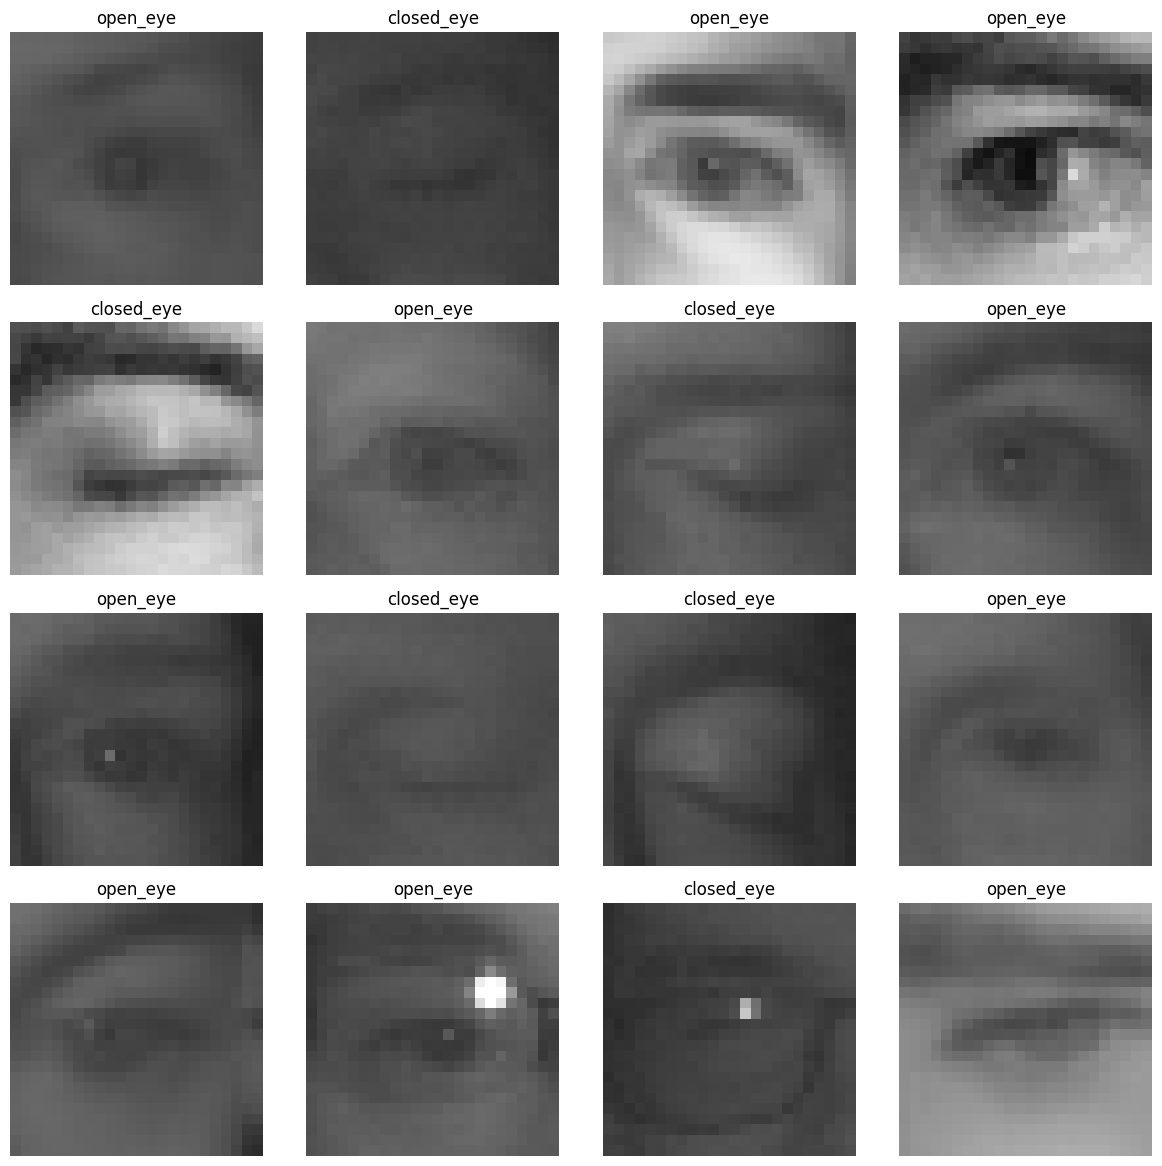

In [9]:
plt.figure(figsize=(12, 12))
for batch_images, batch_labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(batch_images[i].numpy().astype("uint8"))
        plt.title(class_names[batch_labels[i]])
        plt.tight_layout()
        plt.axis("off")


In [10]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1./255), # 0-1 range
])

In [11]:
data_augmentation = tf.keras.Sequential([
  layers.RandomRotation(0.2), # 0.2= rotate factor
  layers.RandomFlip(seed = 42)
])

In [12]:
train_data = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [13]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = len(class_names)
inputs = Input(shape=input_shape)

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights='imagenet',
    input_tensor=inputs,
    pooling='avg'
)

base_model.trainable = False
x = base_model.output
x = Dense(units=128, activation='relu')(x)
outputs = Dense(n_classes, activation='softmax')(x)
model = Model(inputs=inputs, outputs=outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
